****1- Data Collection****


In [ ]:
import pandas as pd
import numpy as np

file_path = 'powerconsumption.csv'

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)

df.info()

display(df.head())

Dataset Shape: (52416, 9)
<class 'pandas.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  str    
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), str(1)
memory usage: 4.3 MB


,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


**2 - Data Cleaning**


In [ ]:
df['Datetime'] = pd.to_datetime(df['Datetime'])

duplicates_count = df.duplicated().sum()

df = df.drop_duplicates()

df.set_index('Datetime', inplace=True)

df_hourly = df.resample('h').mean()

print("Duplicates removed:", duplicates_count)
print("New Dataset Shape (Hourly Data):", df_hourly.shape)
display(df_hourly.head())

Duplicates removed: 0
New Dataset Shape (Hourly Data): (8736, 8)


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
Datetime,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433


***3- Feature Extraction***

In [ ]:
df_hourly['Hour'] = df_hourly.index.hour

df_hourly['Day_of_Week'] = df_hourly.index.dayofweek

df_hourly['Month'] = df_hourly.index.month

df_hourly['Is_Weekend'] = (df_hourly['Day_of_Week'] >= 5).astype(int)

df_hourly['Is_Peak_Hour'] = df_hourly['Hour'].apply(lambda x: 1 if 18 <= x <= 22 else 0)

print("Shape after Feature Extraction:", df_hourly.shape)

display(df_hourly.head())

Shape after Feature Extraction: (8736, 13)


,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3,Hour,Day_of_Week,Month,Is_Weekend,Is_Peak_Hour
Datetime,,,,,,,,,,,,,
2017-01-01 00:00:00,6.196833,75.066667,0.081833,0.063500,0.098833,29197.974683,18026.747720,19252.048193,0,6,1,1,0
2017-01-01 01:00:00,5.548833,77.583333,0.082000,0.056833,0.112500,24657.215190,16078.419453,17042.891567,1,6,1,1,0
2017-01-01 02:00:00,5.054333,78.933333,0.082333,0.063000,0.129167,22083.037973,14330.699088,15676.144578,2,6,1,1,0
2017-01-01 03:00:00,5.004333,77.083333,0.082833,0.059833,0.141000,20811.139240,13219.452887,14883.855422,3,6,1,1,0
2017-01-01 04:00:00,5.097667,74.050000,0.082333,0.058000,0.122833,20475.949367,12921.580547,14317.108433,4,6,1,1,0


***4- Feature Selection***

In [ ]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

target_col = 'PowerConsumption_Zone1'
zone_cols = ['PowerConsumption_Zone1', 'PowerConsumption_Zone2', 'PowerConsumption_Zone3']

X = df_hourly.drop(zone_cols, axis=1)
X = X.select_dtypes(include=[np.number])  
y = df_hourly[target_col]

k = min(5, X.shape[1])

kbest = SelectKBest(score_func=f_regression, k=k)
kbest.fit(X, y)
kbest_features = X.columns[kbest.get_support()].tolist()

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
rf_features = rf_importances.head(k).index.tolist()

print("Method 1 (SelectKBest) Selected:", kbest_features)
print("Method 2 (Random Forest) Selected:", rf_features)
display(pd.DataFrame(rf_importances, columns=['Importance']))

Method 1 (SelectKBest) Selected: ['Temperature', 'Humidity', 'GeneralDiffuseFlows', 'Hour', 'Is_Peak_Hour']
Method 2 (Random Forest) Selected: ['Hour', 'Is_Peak_Hour', 'Temperature', 'Month', 'GeneralDiffuseFlows']


,Importance
Hour,0.622442
Is_Peak_Hour,0.134260
Temperature,0.088846
Month,0.070525
GeneralDiffuseFlows,0.026011
DiffuseFlows,0.016139
Day_of_Week,0.015801
WindSpeed,0.014855
Humidity,0.010169
Is_Weekend,0.000952


***5- Data Imbalance***

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from collections import Counter

threshold = df_hourly[target_col].quantile(0.75)
df_hourly['Consumption_Category'] = (df_hourly[target_col] > threshold).astype(int)

X_imbalance = df_hourly[kbest_features]
y_imbalance = df_hourly['Consumption_Category']

print("Before Balancing:", Counter(y_imbalance))

smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_imbalance, y_imbalance)

print("After Balancing:", Counter(y_res))

Before Balancing: Counter({0: 6552, 1: 2184})
After Balancing: Counter({0: 6552, 1: 6552})


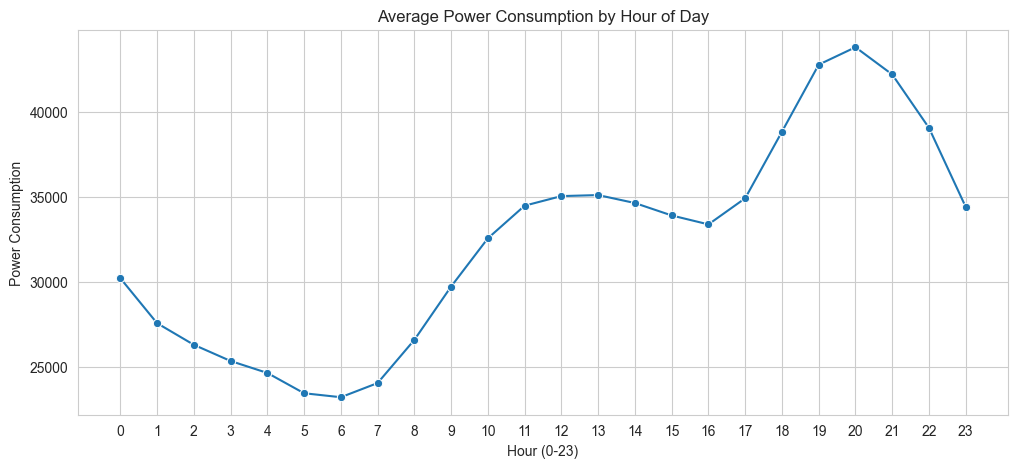

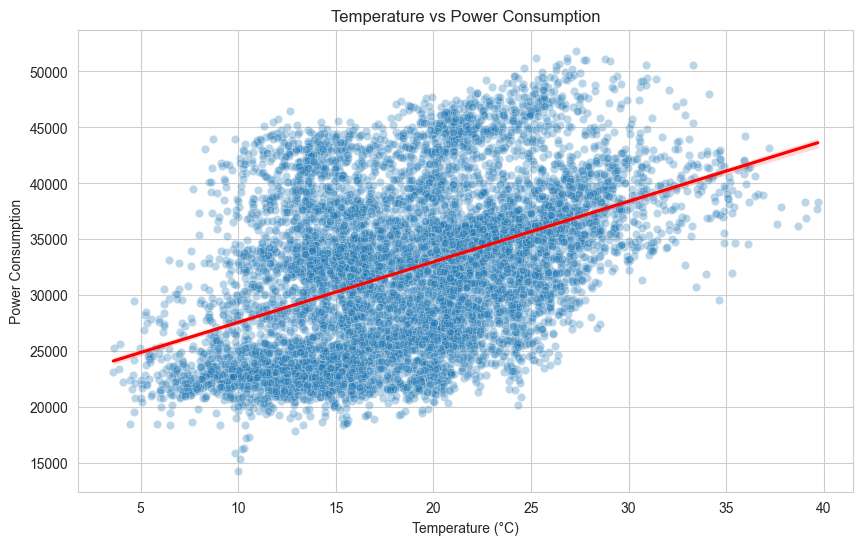

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

hourly_avg = df_hourly.groupby('Hour')[target_col].mean().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=hourly_avg, x='Hour', y=target_col, marker='o')
plt.title('Average Power Consumption by Hour of Day')
plt.xlabel('Hour (0-23)')
plt.ylabel('Power Consumption')
plt.xticks(range(0, 24))
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_hourly, x='Temperature', y=target_col, alpha=0.3)

sns.regplot(data=df_hourly, x='Temperature', y=target_col,
            scatter=False, color='red')

plt.title('Temperature vs Power Consumption')
plt.xlabel('Temperature (°C)')
plt.ylabel('Power Consumption')
plt.show()

***7 - Build Model + Evaluation***

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


X = df_hourly[kbest_features]
y = df_hourly['Consumption_Category']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Before SMOTE:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Before SMOTE:
Accuracy: 0.9210526315789473
              precision    recall  f1-score   support

           0       0.94      0.95      0.95      1316
           1       0.85      0.82      0.84       432

    accuracy                           0.92      1748
   macro avg       0.90      0.89      0.89      1748
weighted avg       0.92      0.92      0.92      1748



In [ ]:
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

model_smote = RandomForestClassifier(random_state=42)
model_smote.fit(X_train_res, y_train_res)

y_pred_res = model_smote.predict(X_test_res)

print("After SMOTE:")
print("Accuracy:", accuracy_score(y_test_res, y_pred_res))
print(classification_report(y_test_res, y_pred_res))

After SMOTE:
Accuracy: 0.9381915299504006
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      1324
           1       0.93      0.95      0.94      1297

    accuracy                           0.94      2621
   macro avg       0.94      0.94      0.94      2621
weighted avg       0.94      0.94      0.94      2621



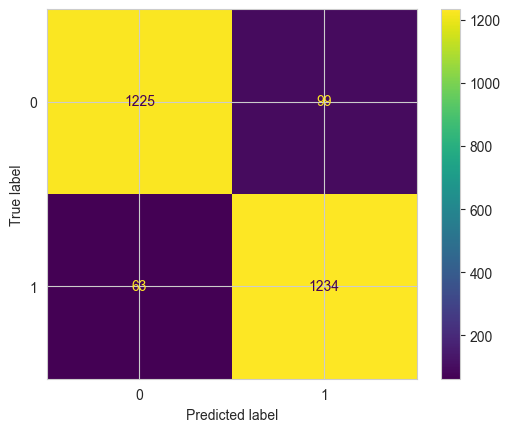

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_res, y_pred_res)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

***Confusion Matrix***

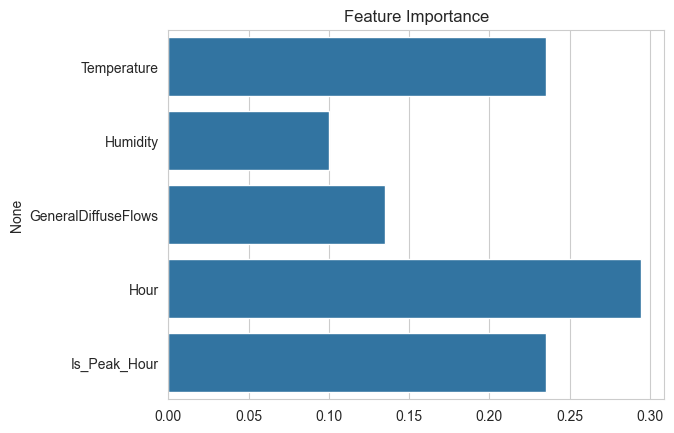

In [ ]:
importances = model_smote.feature_importances_
feat_names = X_res.columns

sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance")
plt.show()

***Feature Importance***

In [ ]:
import joblib

joblib.dump(model_smote, 'model.pkl')
joblib.dump(kbest_features, 'features.pkl')

['features.pkl']

GUI

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import matplotlib.pyplot as plt
import pandas as pd

model = joblib.load('model.pkl')
features = joblib.load('features.pkl')

st.set_page_config(page_title="Electricity Prediction", layout="centered")

st.title("⚡ Electricity Consumption Predictor")
st.markdown("### Enter conditions to predict power consumption")

col1, col2 = st.columns(2)

with col1:
    hour_12 = st.slider("Hour (1-12)", 1, 12, 8)

with col2:
    am_pm = st.selectbox("AM / PM", ["AM", "PM"])

if am_pm == "PM" and hour_12 != 12:
    hour = hour_12 + 12
elif am_pm == "AM" and hour_12 == 12:
    hour = 0
else:
    hour = hour_12

temp = st.number_input("Temperature (°C)", value=30.0)

day_name = st.selectbox("Day", [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
])

day_map = {
    "Monday": 0, "Tuesday": 1, "Wednesday": 2,
    "Thursday": 3, "Friday": 4, "Saturday": 5, "Sunday": 6
}
day = day_map[day_name]

# Weekend
weekend = 1 if day in [5, 6] else 0

# Month
month = st.slider("Month", 1, 12, 7)

# Peak
peak = 1 if 18 <= hour <= 22 else 0

input_dict = {
    "Hour": hour,
    "Temperature": temp,
    "Day_of_Week": day,
    "Month": month,
    "Is_Weekend": weekend,
    "Is_Peak_Hour": peak
}

input_data = [input_dict.get(f, 0) for f in features]

# Prediction
if st.button("🔍 Predict"):

    pred = model.predict([input_data])[0]

    st.subheader("📊 Input Overview")

    data_chart = pd.DataFrame({
        "Feature": ["Hour", "Temperature", "Day", "Month"],
        "Value": [hour, temp, day, month]
    })

    fig, ax = plt.subplots()
    ax.bar(data_chart["Feature"], data_chart["Value"])
    ax.set_title("Input Features")
    st.pyplot(fig)

    reasons = []

    if temp > 30:
        reasons.append(" درجة الحرارة عالية")

    if peak == 1:
        reasons.append(" وقت ذروة (مساء)")

    if weekend == 1:
        reasons.append(" يوم إجازة")

    st.subheader(" Prediction Result")

    if pred == 1:
        st.error(" High Consumption (Peak Load)")

        if reasons:
            st.info(" الأسباب المحتملة:")
            for r in reasons:
                st.write("-", r)

    else:
        st.success(" Normal Consumption")

        if reasons:
            st.info(" رغم وجود بعض العوامل، الاستهلاك طبيعي")


Overwriting app.py


In [ ]:
!pip install streamlit -q

In [ ]:
import os
os.system("streamlit run app.py --server.port 8501 &")